In [152]:
import numpy as np
from scipy.stats import truncnorm
from scipy.stats import rv_continuous
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

In [155]:
import numpy as np
from scipy.stats import rv_continuous, truncnorm


class truncated_gaussian:
    def __init__(self, mu=0.3, sigma=0.3):
        self.mu = mu
        self.sigma = sigma
        # self.lower = lower
        # self.upper = upper

    def truncated_gaussian(self,lower=0, upper=1):
        a, b = (lower - self.mu) / self.sigma, (upper - self.mu) / self.sigma
        return truncnorm(a, b, loc=self.mu, scale=self.sigma)   

    

    def rvs(self,lower,upper, n_s=1, t=None):
        a, b = (lower - self.mu) / self.sigma, (upper - self.mu) / self.sigma
        return truncnorm(a, b, loc=self.mu, scale=self.sigma).rvs(n_s, random_state=t)

# Piecewise Uniform Distribution
class piecewise_uniform(rv_continuous):
    def __init__(self, tau_l, tau_h, beta1=0.01, beta2=0.95):
        super().__init__(a=0, b=1)
        self.tau_l = tau_l
        self.tau_h = tau_h
        self.beta1 = beta1
        self.beta2 = beta2
        self.beta3 = 1 - (beta1 + beta2)
        self.norm1 = beta1 / tau_l
        self.norm2 = beta2 / (tau_h - tau_l)
        self.norm3 = self.beta3 / (1 - tau_h)
        self.weights = [self.beta1, self.beta2, self.beta3]
        self.ranges = [(0, tau_l), (tau_l, tau_h), (tau_h, 1)]

    def _pdf(self, y):
        if y < 0 or y > 1:
            return 0.0
        elif y <= self.tau_l:
            return self.norm1
        elif y <= self.tau_h:
            return self.norm2
        else:
            return self.norm3

    def rvs(self, n_s=1, t=None):
        rng = np.random.default_rng(seed=t)
        region_choices = rng.choice([0, 1, 2], size=n_s, p=self.weights)
        samples = np.zeros(n_s)
        for i, region in enumerate(region_choices):
            low, high = self.ranges[region]
            samples[i] = rng.uniform(low, high)
        return samples

# Utility function
def get_utility(dist, tau_l, tau_h, gamma, n_s=1, t=None):
    samples = np.array(dist.rvs(tau_l,tau_h,n_s=n_s, t=t))
    # filtered = samples[(samples >= tau_l) & (samples <= tau_h)]
    utilities = (2 + gamma) * samples - 1
    return utilities.mean() if n_s > 1 else utilities[0]
    


def get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist, n_s=1, t=None):
    U1 = np.array([
        [get_utility(dist, tau_l, 1, gamma_l, n_s, t)/2, 0, get_utility(dist, tau_h, 1, gamma_l, n_s, t)/2, 0],
        [get_utility(dist, tau_l, 1, gamma_l, n_s, t), get_utility(dist, tau_l, 1, gamma_h, n_s, t)/2, get_utility(dist, tau_h, 1, gamma_l, n_s, t), get_utility(dist, tau_h, 1, gamma_h, n_s, t)/2],
        [get_utility(dist, tau_l, tau_h, gamma_l, n_s, t) + get_utility(dist, tau_h, 1, gamma_l, n_s, t)/2, get_utility(dist, tau_l, tau_h, gamma_h, n_s, t), get_utility(dist, tau_h, 1, gamma_l, n_s, t)/2, 0],
        [get_utility(dist, tau_l, 1, gamma_l, n_s, t), get_utility(dist, tau_l, tau_h, gamma_h, n_s, t) + get_utility(dist, tau_h, 1, gamma_h, n_s, t)/2, get_utility(dist, tau_h, 1, gamma_l, n_s, t), get_utility(dist, tau_h, 1, gamma_h, n_s, t)/2]
    ])
    return U1




In [186]:

# Example use
gamma_l, gamma_h = 0.4, 0.8
mu, sigma = 0.3, 0.1
tau_l, tau_h = 1 / (2 + gamma_h), 1 / (2 + gamma_l)
print(tau_l, tau_h)
dist = truncated_gaussian(mu,sigma)
# dist = piecewise_uniform(tau_l, tau_h)
samples = np.array(dist.rvs(tau_l, 1, n_s=100, t=1))
# print(samples)
print(np.mean((2 + gamma_l)*samples - 1))

U1 = get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist,1000000,1)
print(U1)


0.35714285714285715 0.4166666666666667
0.0004296966605797725
[[ 0.00321907  0.          0.05919588  0.        ]
 [ 0.00643815  0.08708892  0.11839176  0.15239519]
 [-0.01830212  0.07625233  0.05919588  0.        ]
 [ 0.00643815  0.22864753  0.11839176  0.15239519]]


In [189]:
# print(np.mean((2+gamma_l)*samples - 1))
ut = get_utility(dist, tau_l, 1, gamma_l, n_s=100000, t=1)
print(ut)
#comparing with analytical
integrand = lambda y: ((2 + gamma_l) * y - 1) * dist.truncated_gaussian(tau_l,1).pdf(y)
result, _ = quad(integrand, tau_l, 1)
print(result)

0.08371259150828621
0.08400415198946397


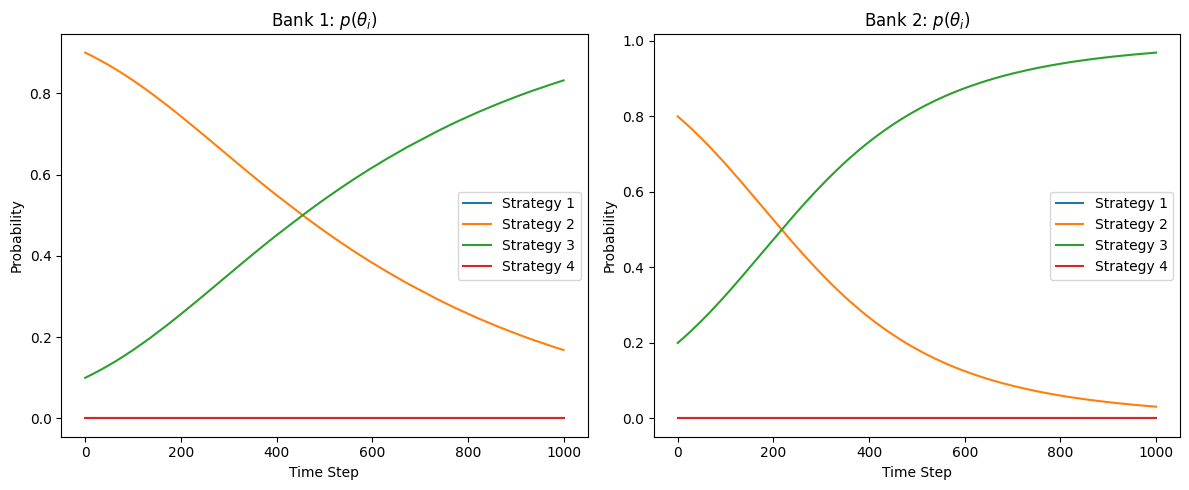

In [191]:
def exponential_weights(T, eta, gamma_l, gamma_h, tau_l, tau_h, dist, n_s, num_actions):
    
    # p1 = np.ones((T+1, num_actions)) / num_actions
    # p2 = np.ones((T+1, num_actions)) / num_actions

    p1 = np.tile((0, 0.9, 0.1, 0), (T+1, 1))
    p2 = np.tile((0, 0.8, 0.2, 0), (T+1, 1))
    
    
    
    # Simulate algorithm
    for t in range(T):
        U1 = get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist, n_s, t)
        U2 = U1  # Assume zero-sum game for illustration
        for k in range(num_actions):
            # Compute utilities using sampled strategy of the current player
            util1 = np.array([p2[t, j]*U1[j, k] for j in range(num_actions)])
            util2 = np.array([p1[t, j]*U2[j, k] for j in range(num_actions)])
        
            # Update probabilities using exponential weights
            p1[t+1, k] = p1[t, k] * np.exp(eta * util1.sum())
            p2[t+1, k] = p2[t, k] * np.exp(eta * util2.sum())
    
        # Normalize
        p1[t+1] /= np.sum(p1[t+1])
        p2[t+1] /= np.sum(p2[t+1])
    return p1, p2

def plot_probabilities_per_player(p1, p2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for i in range(4):
        plt.plot(p1[:, i], label=f'Strategy {i+1}')
    plt.title(r'Bank 1: $p(\theta_i)$')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for i in range(4):
        plt.plot(p2[:, i], label=f'Strategy {i+1}')
    plt.title(r'Bank 2: $p(\theta_i)$')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


T = 1000  # time steps
eta = 0.1  # learning rate
num_actions = 4  # 4 strategy pairs per player
gamma_l, gamma_h = 0.4, 0.8
mu, sigma = 0.1, 0.2
tau_l, tau_h = 1/(2+gamma_h), 1/(2+gamma_l)
tau_l, tau_h
dist = truncated_gaussian(mu,sigma)
# dist = piecewise_uniform(tau_l, tau_h)
n_s = 10000
p1, p2 = exponential_weights(T, eta, gamma_l, gamma_h, tau_l, tau_h, \
                              dist, n_s, num_actions)
plot_probabilities_per_player(p1, p2)

In [61]:

# Example use
gamma_l, gamma_h = 0.4, 0.8
mu, sigma = 0.3, 0.1
tau_l, tau_h = 1 / (2 + gamma_h), 1 / (2 + gamma_l)
print(tau_l, tau_h)
dist = truncated_gaussian(mu,sigma, tau_l, tau_h)
U1 = get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist,1,1)
# U1
pp = get_utility(dist, tau_l, tau_h, gamma_h, n_s=1, t=None)
pp




0.35714285714285715 0.4166666666666667


np.float64(0.09367152458479011)